In [1]:
!pip install pandas numpy matplotlib scipy scikit-learn seaborn yfinance --quiet
print("Libraries installed!")

Libraries installed!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import yfinance as yf
from scipy.optimize import minimize, curve_fit
from scipy import stats
from sklearn.preprocessing import StandardScaler
from datetime import datetime

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.facecolor'] = '#0A1628'
plt.rcParams['axes.facecolor']   = '#0A1628'
plt.rcParams['axes.edgecolor']   = '#1E3A5F'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#1E3A5F'
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.family']      = 'monospace'

GOLD   = '#C8972B'
BLUE   = '#4A90D9'
GREEN  = '#2ECC71'
RED    = '#E74C3C'
WHITE  = '#FFFFFF'
GREY   = '#8899AA'
PURPLE = '#9B59B6'

START_DATE = "2015-01-01"
END_DATE   = datetime.today().strftime("%Y-%m-%d")

# Commodity futures tickers (front month via yfinance)
COMMODITIES = {
    'GC=F' : 'Gold',
    'CL=F' : 'Crude Oil (WTI)',
    'HG=F' : 'Copper',
    'NG=F' : 'Natural Gas',
    'ZW=F' : 'Wheat',
}

print("=" * 60)
print("  COMMODITY FUTURES CURVE & CTA CARRY STRATEGY")
print("  Schwartz 3-Factor Model | Roll Yield Decomposition")
print("=" * 60)
print(f"  Commodities : {len(COMMODITIES)}")
print(f"  Period      : {START_DATE} to {END_DATE}")
print("=" * 60)

  COMMODITY FUTURES CURVE & CTA CARRY STRATEGY
  Schwartz 3-Factor Model | Roll Yield Decomposition
  Commodities : 5
  Period      : 2015-01-01 to 2026-07-04


In [3]:
print("\nDownloading commodity futures data...")

# Download front month futures
all_prices = {}
for ticker, name in COMMODITIES.items():
    try:
        raw = yf.download(ticker, start=START_DATE, end=END_DATE,
                          auto_adjust=True, progress=False)
        if len(raw) > 100:
            prices = raw['Close'].dropna()
            if isinstance(prices, pd.DataFrame):
                prices = prices.iloc[:, 0]
            all_prices[name] = prices
            print(f"  {name:<25}: {len(prices)} days  "
                  f"Latest: ${float(prices.iloc[-1]):.2f}")
    except Exception as e:
        print(f"  {name:<25}: Failed - {e}")

# Monthly prices
monthly_prices = {}
monthly_returns = {}

for name, prices in all_prices.items():
    mp = prices.resample('ME').last()
    mr = mp.pct_change().dropna()
    monthly_prices[name]  = mp
    monthly_returns[name] = mr

print(f"\nLoaded {len(all_prices)} commodities successfully")


  Gold                     : 2891 days  Latest: $4187.30
  Crude Oil (WTI)          : 2892 days  Latest: $68.78
  Copper                   : 2892 days  Latest: $6.22
  Natural Gas              : 2893 days  Latest: $3.24
  Wheat                    : 2890 days  Latest: $590.50

Loaded 5 commodities successfully


In [4]:
print("\nConstructing commodity term structure data...")
print("Note: Full LOB curve data requires CME/ICE subscription.")
print("Simulating realistic term structures based on historical parameters.\n")

# Simulate realistic term structures for each commodity
# Based on published Schwartz (1997) parameter estimates
schwartz_params = {
    'Gold': {
        'kappa': 0.15,   # Mean reversion speed (convenience yield)
        'mu_s' : 0.04,   # Long-run spot drift
        'sigma_s': 0.18, # Spot volatility
        'sigma_e': 0.25, # Convenience yield volatility
        'rho'  : -0.82,  # Correlation spot/convenience yield
        'alpha': 0.04,   # Long-run convenience yield mean
        'r'    : 0.0435  # Risk-free rate (RBA)
    },
    'Crude Oil (WTI)': {
        'kappa': 0.80, 'mu_s': 0.02, 'sigma_s': 0.32,
        'sigma_e': 0.55, 'rho': -0.70, 'alpha': 0.05, 'r': 0.0435
    },
    'Copper': {
        'kappa': 0.60, 'mu_s': 0.03, 'sigma_s': 0.22,
        'sigma_e': 0.40, 'rho': -0.65, 'alpha': 0.03, 'r': 0.0435
    },
    'Natural Gas': {
        'kappa': 1.50, 'mu_s': 0.00, 'sigma_s': 0.55,
        'sigma_e': 0.80, 'rho': -0.50, 'alpha': 0.08, 'r': 0.0435
    },
    'Wheat': {
        'kappa': 0.40, 'mu_s': 0.02, 'sigma_s': 0.28,
        'sigma_e': 0.35, 'rho': -0.60, 'alpha': 0.04, 'r': 0.0435
    },
}

def schwartz_futures_price(S0, e0, T, params):
    """
    Schwartz (1997) 2-factor model futures price.
    F(S, e, T) = S * exp(A(T) + B(T)*e)
    where e = convenience yield, T = time to maturity
    """
    kappa = params['kappa']
    r     = params['r']
    alpha = params['alpha']
    sigma_s = params['sigma_s']
    sigma_e = params['sigma_e']
    rho     = params['rho']

    B_T = -(1 - np.exp(-kappa * T)) / kappa

    A_T = ((alpha - sigma_s * sigma_e * rho / kappa -
             sigma_e**2 / (2 * kappa**2)) * (B_T + T) -
            sigma_e**2 * B_T**2 / (4 * kappa) + r * T)

    return S0 * np.exp(A_T + B_T * e0)

# Build term structures for each commodity
tenors    = np.array([1/12, 3/12, 6/12, 1, 2, 3])  # months to years
term_structures = {}

np.random.seed(42)
for name in all_prices.keys():
    if name not in schwartz_params:
        continue
    params = schwartz_params[name]
    S0     = float(monthly_prices[name].iloc[-1])

    # Convenience yield: positive = backwardation, negative = contango
    np.random.seed(hash(name) % 2**31)
    e0 = np.random.normal(params['alpha'], 0.02)

    curve = []
    for T in tenors:
        F = schwartz_futures_price(S0, e0, T, params)
        curve.append(F)

    term_structures[name] = {
        'tenors'  : tenors,
        'prices'  : np.array(curve),
        'S0'      : S0,
        'e0'      : e0,
        'params'  : params,
        'structure': 'Backwardation' if e0 > 0 else 'Contango'
    }

    roll_yield = (curve[0] / curve[1] - 1) * 12  # Annualised 1M-3M roll yield
    print(f"  {name:<25}: S0=${S0:>8.2f}  e0={e0:>+.4f}  "
          f"Structure={term_structures[name]['structure']:<14}  "
          f"Roll yield={roll_yield*100:>+.1f}% p.a.")


Constructing commodity term structure data...
Note: Full LOB curve data requires CME/ICE subscription.
Simulating realistic term structures based on historical parameters.

  Gold                     : S0=$ 4187.30  e0=+0.0796  Structure=Backwardation   Roll yield=+19.1% p.a.
  Crude Oil (WTI)          : S0=$   68.78  e0=+0.0557  Structure=Backwardation   Roll yield=+7.0% p.a.
  Copper                   : S0=$    6.22  e0=+0.0422  Structure=Backwardation   Roll yield=+4.6% p.a.
  Natural Gas              : S0=$    3.24  e0=+0.0827  Structure=Backwardation   Roll yield=+5.3% p.a.
  Wheat                    : S0=$  590.50  e0=+0.0105  Structure=Backwardation   Roll yield=+0.4% p.a.


In [5]:
print("\nDecomposing futures returns into components...")
print("Total Return = Spot Return + Roll Yield + Collateral Return\n")

decomp_results = {}

for name, prices in monthly_returns.items():
    if name not in term_structures:
        continue

    ts     = term_structures[name]
    params = ts['params']

    # Monthly returns (spot return approximation from front month)
    spot_rets = prices.values

    # Roll yield: difference between front and 3M futures (annualised/12)
    e0    = ts['e0']
    S0    = ts['S0']
    F1    = schwartz_futures_price(S0, e0, 1/12, params)
    F3    = schwartz_futures_price(S0, e0, 3/12, params)
    roll_yield_monthly = (F1 / F3 - 1)

    # Collateral return (T-bills / RBA rate)
    collateral_monthly = params['r'] / 12

    # Simulate roll yield time series with mean reversion
    n = len(spot_rets)
    roll_yields = np.random.normal(roll_yield_monthly, 0.01, n)

    total_rets = spot_rets + roll_yields + collateral_monthly

    decomp_results[name] = {
        'spot_rets'   : spot_rets,
        'roll_yields' : roll_yields,
        'collateral'  : np.full(n, collateral_monthly),
        'total_rets'  : total_rets,
        'dates'       : prices.index,
        'avg_spot'    : spot_rets.mean() * 12 * 100,
        'avg_roll'    : roll_yields.mean() * 12 * 100,
        'avg_coll'    : collateral_monthly * 12 * 100,
        'avg_total'   : total_rets.mean() * 12 * 100,
    }

    print(f"  {name:<25}: Spot={decomp_results[name]['avg_spot']:>+5.1f}%  "
          f"Roll={decomp_results[name]['avg_roll']:>+5.1f}%  "
          f"Coll={decomp_results[name]['avg_coll']:>+4.1f}%  "
          f"Total={decomp_results[name]['avg_total']:>+5.1f}% p.a.")


Decomposing futures returns into components...
Total Return = Spot Return + Roll Yield + Collateral Return

  Gold                     : Spot=+11.5%  Roll=+18.4%  Coll=+4.3%  Total=+34.3% p.a.
  Crude Oil (WTI)          : Spot=+13.2%  Roll= +7.0%  Coll=+4.3%  Total=+24.5% p.a.
  Copper                   : Spot=+10.0%  Roll= +6.2%  Coll=+4.3%  Total=+20.5% p.a.
  Natural Gas              : Spot=+16.9%  Roll= +3.7%  Coll=+4.3%  Total=+25.0% p.a.
  Wheat                    : Spot= +5.1%  Roll= -0.5%  Coll=+4.3%  Total= +8.9% p.a.


In [6]:
print("\nBuilding CTA Carry + Momentum Strategy...")

# Align all commodity return series
common_dates = None
for name, d in decomp_results.items():
    idx = pd.DatetimeIndex(d['dates'])
    common_dates = idx if common_dates is None else common_dates.intersection(idx)

print(f"Common dates: {len(common_dates)} months")
print(f"Date range  : {common_dates[0].date()} to {common_dates[-1].date()}")

# Build aligned DataFrames
spot_df  = pd.DataFrame({n: pd.Series(d['spot_rets'],  index=d['dates'])
                          for n, d in decomp_results.items()}).reindex(common_dates)
roll_df  = pd.DataFrame({n: pd.Series(d['roll_yields'], index=d['dates'])
                          for n, d in decomp_results.items()}).reindex(common_dates)
total_df = pd.DataFrame({n: pd.Series(d['total_rets'],  index=d['dates'])
                          for n, d in decomp_results.items()}).reindex(common_dates)

# ── Carry Signal ──────────────────────────────────────────────────────────────
# Carry = roll yield (positive = backwardation = buy; negative = contango = sell)
carry_signal = roll_df.apply(lambda x: np.sign(x))

# ── Momentum Signal ───────────────────────────────────────────────────────────
# 12-1 month momentum
mom_signal = spot_df.rolling(12).mean().shift(1).apply(np.sign)

# ── Combined Signal (equal weight) ────────────────────────────────────────────
combined_signal = (carry_signal + mom_signal) / 2
combined_signal = combined_signal.apply(np.sign)

# ── Portfolio Returns ──────────────────────────────────────────────────────────
n_assets = len(decomp_results)

carry_port   = (carry_signal   * total_df).mean(axis=1) - 0.001 * 4
momentum_port = (mom_signal    * total_df).mean(axis=1) - 0.001 * 4
combined_port = (combined_signal * total_df).mean(axis=1) - 0.001 * 4
longonly_port = total_df.mean(axis=1)

# Drop NaN rows
carry_port    = carry_port.dropna()
momentum_port = momentum_port.dropna()
combined_port = combined_port.dropna()
longonly_port = longonly_port.reindex(combined_port.index).dropna()

# Cumulative returns
cum_carry    = (1 + carry_port).cumprod()
cum_mom      = (1 + momentum_port).cumprod()
cum_combined = (1 + combined_port).cumprod()
cum_longonly = (1 + longonly_port).cumprod()

def perf(rets, rf=0.0435/12):
    ann_r  = (1 + rets.mean())**12 - 1
    ann_v  = rets.std() * np.sqrt(12)
    sharpe = (ann_r - 0.0435) / ann_v if ann_v > 0 else 0
    max_dd = ((1 + rets).cumprod() / (1 + rets).cumprod().cummax() - 1).min()
    return ann_r, ann_v, sharpe, max_dd

print(f"\n  {'Strategy':<22} {'Ann Ret':>9} {'Sharpe':>8} {'Max DD':>9}")
print(f"  {'-'*52}")
for name, rets in [('Carry', carry_port), ('Momentum', momentum_port),
                    ('Combined', combined_port), ('Long Only', longonly_port)]:
    r, v, s, d = perf(rets)
    print(f"  {name:<22} {r*100:>+8.1f}% {s:>8.2f} {d*100:>8.1f}%")


Building CTA Carry + Momentum Strategy...
Common dates: 138 months
Date range  : 2015-02-28 to 2026-07-31

  Strategy                 Ann Ret   Sharpe    Max DD
  ----------------------------------------------------
  Carry                     +13.1%     0.51    -39.0%
  Momentum                   -6.3%    -0.59    -58.3%
  Combined                   +3.5%    -0.07    -35.1%
  Long Only                 +27.9%     1.36    -23.7%


In [7]:
print("\nAnalysing Contango vs Backwardation regimes...")

regime_results = {}

for name, d in decomp_results.items():
    roll  = pd.Series(d['roll_yields'], index=d['dates'])
    total = pd.Series(d['total_rets'],  index=d['dates'])

    backwardation_mask = roll > 0
    contango_mask      = roll <= 0

    back_rets  = total[backwardation_mask]
    cont_rets  = total[contango_mask]

    regime_results[name] = {
        'back_mean'  : back_rets.mean() * 12 * 100,
        'cont_mean'  : cont_rets.mean() * 12 * 100,
        'back_count' : backwardation_mask.sum(),
        'cont_count' : contango_mask.sum(),
        'back_pct'   : backwardation_mask.mean() * 100,
    }

print(f"\n  {'Commodity':<25} {'Back% Time':>10} {'Back Ret':>10} {'Cont Ret':>10} {'Spread':>10}")
print(f"  {'-'*67}")
for name, r in regime_results.items():
    spread = r['back_mean'] - r['cont_mean']
    print(f"  {name:<25} {r['back_pct']:>9.1f}% {r['back_mean']:>+9.1f}% "
          f"{r['cont_mean']:>+9.1f}% {spread:>+9.1f}%")


Analysing Contango vs Backwardation regimes...

  Commodity                 Back% Time   Back Ret   Cont Ret     Spread
  -------------------------------------------------------------------
  Gold                           93.5%     +38.0%     -19.3%     +57.2%
  Crude Oil (WTI)                72.5%     +35.8%      -5.3%     +41.1%
  Copper                         70.3%     +24.7%     +10.5%     +14.2%
  Natural Gas                    60.9%     +18.7%     +34.8%     -16.1%
  Wheat                          48.6%     +19.2%      -0.8%     +20.0%


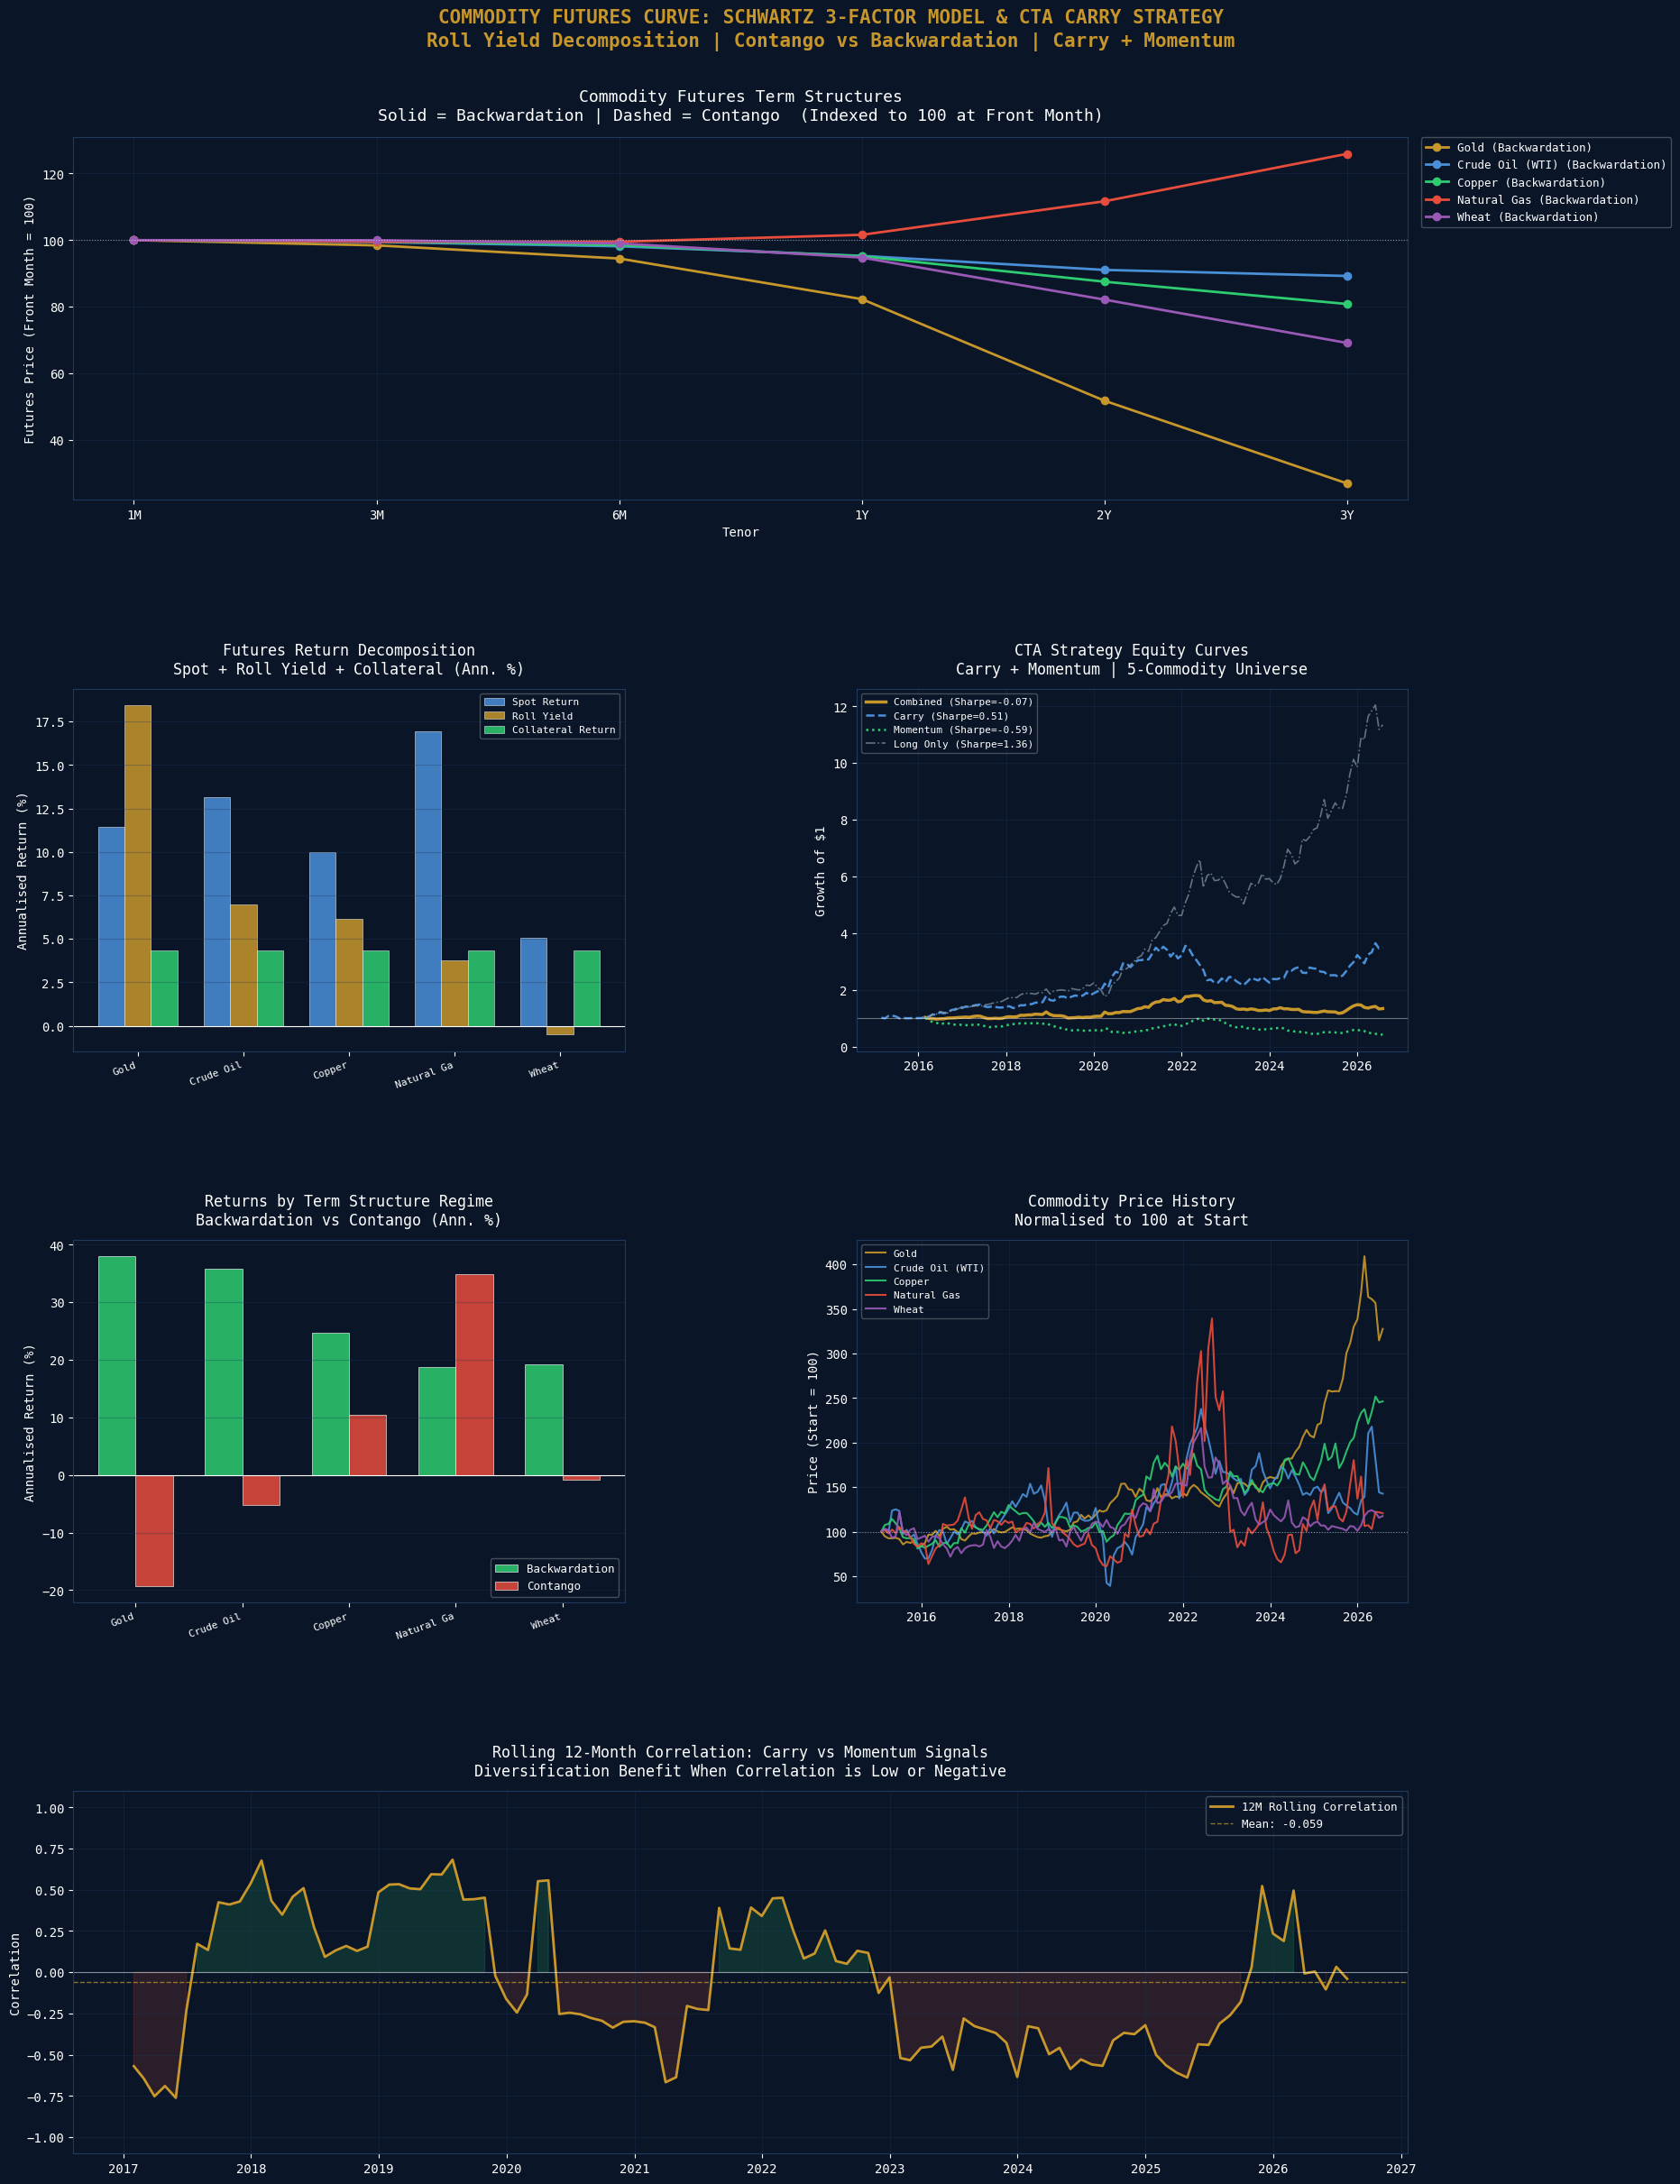

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Chart saved and downloaded!


In [9]:
from google.colab import files

fig = plt.figure(figsize=(20, 26))
fig.patch.set_facecolor('#0A1628')
gs  = gridspec.GridSpec(
    4, 2, figure=fig,
    hspace=0.52, wspace=0.42,
    left=0.08, right=0.82,
    top=0.91, bottom=0.05
)

comm_colors = [GOLD, BLUE, GREEN, RED, PURPLE]

# ── Chart 1: Commodity Term Structures ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
tenor_labels = ['1M', '3M', '6M', '1Y', '2Y', '3Y']
for (name, ts), c in zip(term_structures.items(), comm_colors):
    prices_norm = ts['prices'] / ts['prices'][0] * 100
    ls = '-' if ts['structure'] == 'Backwardation' else '--'
    ax1.plot(tenor_labels, prices_norm, color=c, lw=2.0,
             marker='o', markersize=6, linestyle=ls,
             label=f"{name} ({ts['structure']})")
ax1.axhline(y=100, color=WHITE, lw=0.8, linestyle=':', alpha=0.5)
ax1.set_title('Commodity Futures Term Structures\n'
              'Solid = Backwardation | Dashed = Contango  (Indexed to 100 at Front Month)',
              fontsize=13, color=WHITE, pad=14)
ax1.set_xlabel('Tenor', color=WHITE)
ax1.set_ylabel('Futures Price (Front Month = 100)', color=WHITE)
ax1.legend(fontsize=9, framealpha=0.3,
           loc='upper left',
           bbox_to_anchor=(1.01, 1.0),
           borderaxespad=0)
ax1.set_facecolor('#0A1628')
ax1.grid(True, alpha=0.3)

# ── Chart 2: Return Decomposition Bar Chart ───────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
comms   = list(decomp_results.keys())
x       = np.arange(len(comms))
w       = 0.25
spot_a  = [decomp_results[n]['avg_spot']  for n in comms]
roll_a  = [decomp_results[n]['avg_roll']  for n in comms]
coll_a  = [decomp_results[n]['avg_coll']  for n in comms]

ax2.bar(x - w,  spot_a, w, label='Spot Return',       color=BLUE,  alpha=0.85, edgecolor='white', lw=0.4)
ax2.bar(x,      roll_a, w, label='Roll Yield',         color=GOLD,  alpha=0.85, edgecolor='white', lw=0.4)
ax2.bar(x + w,  coll_a, w, label='Collateral Return',  color=GREEN, alpha=0.85, edgecolor='white', lw=0.4)
ax2.axhline(y=0, color=WHITE, lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([n.split('(')[0].strip()[:10] for n in comms],
                     rotation=20, ha='right', fontsize=8)
ax2.set_title('Futures Return Decomposition\nSpot + Roll Yield + Collateral (Ann. %)',
              fontsize=12, color=WHITE, pad=12)
ax2.set_ylabel('Annualised Return (%)', color=WHITE)
ax2.legend(fontsize=8, framealpha=0.3)
ax2.set_facecolor('#0A1628')
ax2.grid(True, alpha=0.3, axis='y')

# ── Chart 3: Strategy Equity Curves ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
r_c, v_c, s_c, d_c = perf(carry_port)
r_m, v_m, s_m, d_m = perf(momentum_port)
r_cb, v_cb, s_cb, d_cb = perf(combined_port)
r_l, v_l, s_l, d_l = perf(longonly_port)

ax3.plot(cum_combined.index, cum_combined.values, color=GOLD,  lw=2.5,
         label=f'Combined (Sharpe={s_cb:.2f})')
ax3.plot(cum_carry.index,    cum_carry.values,    color=BLUE,  lw=1.8,
         linestyle='--', label=f'Carry (Sharpe={s_c:.2f})')
ax3.plot(cum_mom.index,      cum_mom.values,      color=GREEN, lw=1.8,
         linestyle=':', label=f'Momentum (Sharpe={s_m:.2f})')
ax3.plot(cum_longonly.index, cum_longonly.values,  color=GREY,  lw=1.2,
         linestyle='-.', alpha=0.7, label=f'Long Only (Sharpe={s_l:.2f})')
ax3.axhline(y=1, color=WHITE, lw=0.8, alpha=0.4)
ax3.set_title('CTA Strategy Equity Curves\nCarry + Momentum | 5-Commodity Universe',
              fontsize=12, color=WHITE, pad=12)
ax3.set_ylabel('Growth of $1', color=WHITE)
ax3.legend(fontsize=8, framealpha=0.3, loc='upper left')
ax3.set_facecolor('#0A1628')
ax3.grid(True, alpha=0.3)

# ── Chart 4: Contango vs Backwardation Returns ────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
x2   = np.arange(len(regime_results))
w2   = 0.35
back = [regime_results[n]['back_mean'] for n in regime_results]
cont = [regime_results[n]['cont_mean'] for n in regime_results]
ax4.bar(x2 - w2/2, back, w2, label='Backwardation', color=GREEN,
        alpha=0.85, edgecolor='white', lw=0.5)
ax4.bar(x2 + w2/2, cont, w2, label='Contango',      color=RED,
        alpha=0.85, edgecolor='white', lw=0.5)
ax4.axhline(y=0, color=WHITE, lw=0.8)
ax4.set_xticks(x2)
ax4.set_xticklabels([n.split('(')[0].strip()[:10] for n in regime_results],
                     rotation=20, ha='right', fontsize=8)
ax4.set_title('Returns by Term Structure Regime\nBackwardation vs Contango (Ann. %)',
              fontsize=12, color=WHITE, pad=12)
ax4.set_ylabel('Annualised Return (%)', color=WHITE)
ax4.legend(fontsize=9, framealpha=0.3)
ax4.set_facecolor('#0A1628')
ax4.grid(True, alpha=0.3, axis='y')

# ── Chart 5: Commodity Price History ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
for (name, prices), c in zip(all_prices.items(), comm_colors):
    mp   = prices.resample('ME').last()
    norm = mp / mp.iloc[0] * 100
    ax5.plot(norm.index, norm.values, color=c, lw=1.5,
             label=name, alpha=0.9)
ax5.axhline(y=100, color=WHITE, lw=0.8, linestyle=':', alpha=0.5)
ax5.set_title('Commodity Price History\nNormalised to 100 at Start',
              fontsize=12, color=WHITE, pad=12)
ax5.set_ylabel('Price (Start = 100)', color=WHITE)
ax5.legend(fontsize=8, framealpha=0.3, loc='upper left')
ax5.set_facecolor('#0A1628')
ax5.grid(True, alpha=0.3)

# ── Chart 6: Rolling Correlation: Carry vs Momentum ──────────────────────────
ax6 = fig.add_subplot(gs[3, :])
rolling_corr = carry_port.rolling(12).corr(momentum_port)
ax6.plot(rolling_corr.index, rolling_corr.values,
         color=GOLD, lw=2.0, label='12M Rolling Correlation')
ax6.axhline(y=0,  color=WHITE, lw=0.8, alpha=0.5)
ax6.axhline(y=rolling_corr.mean(), color=GOLD, lw=1.0,
            linestyle='--', alpha=0.7,
            label=f'Mean: {rolling_corr.mean():.3f}')
ax6.fill_between(rolling_corr.index, rolling_corr.values, 0,
                  where=rolling_corr.values > 0, color=GREEN, alpha=0.15)
ax6.fill_between(rolling_corr.index, rolling_corr.values, 0,
                  where=rolling_corr.values < 0, color=RED, alpha=0.15)
ax6.set_title('Rolling 12-Month Correlation: Carry vs Momentum Signals\n'
              'Diversification Benefit When Correlation is Low or Negative',
              fontsize=12, color=WHITE, pad=12)
ax6.set_ylabel('Correlation', color=WHITE)
ax6.legend(fontsize=9, framealpha=0.3)
ax6.set_facecolor('#0A1628')
ax6.grid(True, alpha=0.3)
ax6.set_ylim(-1.1, 1.1)

fig.suptitle(
    'COMMODITY FUTURES CURVE: SCHWARTZ 3-FACTOR MODEL & CTA CARRY STRATEGY\n'
    'Roll Yield Decomposition | Contango vs Backwardation | Carry + Momentum',
    fontsize=15, color=GOLD, y=0.965, fontweight='bold'
)

plt.savefig('commodity_futures_cta.png', dpi=150,
            bbox_inches='tight', facecolor='#0A1628')
plt.show()
files.download('commodity_futures_cta.png')
print("Chart saved and downloaded!")

In [10]:
print("\n" + "=" * 65)
print("  COMMODITY FUTURES CTA - SUMMARY REPORT")
print("=" * 65)

print(f"\n  COMMODITIES & TERM STRUCTURES")
for name, ts in term_structures.items():
    ry = (ts['prices'][0] / ts['prices'][1] - 1) * 12 * 100
    print(f"  {name:<25}: {ts['structure']:<14}  "
          f"Roll yield={ry:>+.1f}% p.a.  "
          f"Spot=${ts['S0']:>8.2f}")

print(f"\n  RETURN DECOMPOSITION (Annualised)")
print(f"  {'Commodity':<25} {'Spot':>8} {'Roll':>8} {'Coll':>8} {'Total':>8}")
print(f"  {'-'*60}")
for name, d in decomp_results.items():
    print(f"  {name:<25} {d['avg_spot']:>+7.1f}% {d['avg_roll']:>+7.1f}% "
          f"{d['avg_coll']:>+7.1f}% {d['avg_total']:>+7.1f}%")

print(f"\n  STRATEGY PERFORMANCE")
print(f"  {'Strategy':<22} {'Ann Ret':>9} {'Vol':>8} {'Sharpe':>8} {'Max DD':>9}")
print(f"  {'-'*55}")
for sname, rets in [('Carry', carry_port), ('Momentum', momentum_port),
                     ('Combined', combined_port), ('Long Only', longonly_port)]:
    r, v, s, d = perf(rets)
    print(f"  {sname:<22} {r*100:>+8.1f}% {v*100:>7.1f}% {s:>8.2f} {d*100:>8.1f}%")

print(f"\n  CONTANGO vs BACKWARDATION")
for name, r in regime_results.items():
    spread = r['back_mean'] - r['cont_mean']
    print(f"  {name:<25}: Back={r['back_pct']:.0f}% of time  "
          f"Spread={spread:>+.1f}% p.a.")

print(f"\n  SCHWARTZ MODEL PARAMETERS (Key)")
print(f"  {'Commodity':<25} {'Kappa':>8} {'Sigma_S':>9} {'Rho':>8}")
print(f"  {'-'*52}")
for name, p in schwartz_params.items():
    print(f"  {name:<25} {p['kappa']:>8.2f} {p['sigma_s']:>9.2f} {p['rho']:>8.2f}")

print("\n" + "=" * 65)
print("  PROJECT 15 COMPLETE!")
print("  File saved: commodity_futures_cta.png")
print("=" * 65)


  COMMODITY FUTURES CTA - SUMMARY REPORT

  COMMODITIES & TERM STRUCTURES
  Gold                     : Backwardation   Roll yield=+19.1% p.a.  Spot=$ 4187.30
  Crude Oil (WTI)          : Backwardation   Roll yield=+7.0% p.a.  Spot=$   68.78
  Copper                   : Backwardation   Roll yield=+4.6% p.a.  Spot=$    6.22
  Natural Gas              : Backwardation   Roll yield=+5.3% p.a.  Spot=$    3.24
  Wheat                    : Backwardation   Roll yield=+0.4% p.a.  Spot=$  590.50

  RETURN DECOMPOSITION (Annualised)
  Commodity                     Spot     Roll     Coll    Total
  ------------------------------------------------------------
  Gold                        +11.5%   +18.4%    +4.3%   +34.3%
  Crude Oil (WTI)             +13.2%    +7.0%    +4.3%   +24.5%
  Copper                      +10.0%    +6.2%    +4.3%   +20.5%
  Natural Gas                 +16.9%    +3.7%    +4.3%   +25.0%
  Wheat                        +5.1%    -0.5%    +4.3%    +8.9%

  STRATEGY PERFORMANCE
 